In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv('hour.csv')

In [15]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [9]:
df.shape

(17379, 17)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [25]:
df["dteday"] = pd.to_datetime(df["dteday"])

In [27]:
df["dteday"].dtype

dtype('<M8[ns]')

In [31]:
df["dteday"].min()

Timestamp('2011-01-01 00:00:00')

In [33]:
df["dteday"].max()

Timestamp('2012-12-31 00:00:00')

In [35]:
df["dteday"].nunique()

731

In [37]:
df.groupby("dteday")["hr"].count().value_counts().sort_index()

hr
1       1
8       1
11      1
12      1
16      1
17      1
18      2
22      6
23     62
24    655
Name: count, dtype: int64

In [61]:
daily_counts = df.groupby("dteday")["hr"].count() < 24
daily_counts = daily_counts.value_counts()

In [63]:
daily_counts

hr
False    655
True      76
Name: count, dtype: int64

In [79]:
incomplete_days = df.groupby("dteday")["hr"].count()
incomplete_days = incomplete_days[incomplete_days < 24]

In [85]:
incomplete_days

dteday
2011-01-02    23
2011-01-03    22
2011-01-04    23
2011-01-05    23
2011-01-06    23
              ..
2012-10-30    11
2012-11-08    23
2012-11-29    23
2012-12-24    23
2012-12-25    23
Name: hr, Length: 76, dtype: int64

In [89]:
df[df["dteday"] == "2012-10-30"]["hr"]

15884    13
15885    14
15886    15
15887    16
15888    17
15889    18
15890    19
15891    20
15892    21
15893    22
15894    23
Name: hr, dtype: int64

In [93]:
df.groupby("dteday")["hr"].agg(["min", "max", "count"])

,min,max,count
dteday,,,
2011-01-01,0,23,24
2011-01-02,0,23,23
2011-01-03,0,23,22
2011-01-04,0,23,23
2011-01-05,0,23,23
...,...,...,...
2012-12-27,0,23,24
2012-12-28,0,23,24
2012-12-29,0,23,24


In [101]:
daily_counts = df.groupby("dteday")["hr"].count()
incomplete_days = daily_counts[daily_counts < 24]

In [105]:
incomplete_days.head(10)

dteday
2011-01-02    23
2011-01-03    22
2011-01-04    23
2011-01-05    23
2011-01-06    23
2011-01-07    23
2011-01-11    22
2011-01-12    22
2011-01-14    23
2011-01-18    12
Name: hr, dtype: int64

In [111]:
df[df["dteday"] == "2011-01-02"]["hr"].tolist()

[0,
 1,
 2,
 3,
 4,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23]

In [131]:
missing_hours = 731 - df.groupby("hr")["dteday"].count()

In [133]:
missing_hours

hr
0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3
Name: dteday, dtype: int64

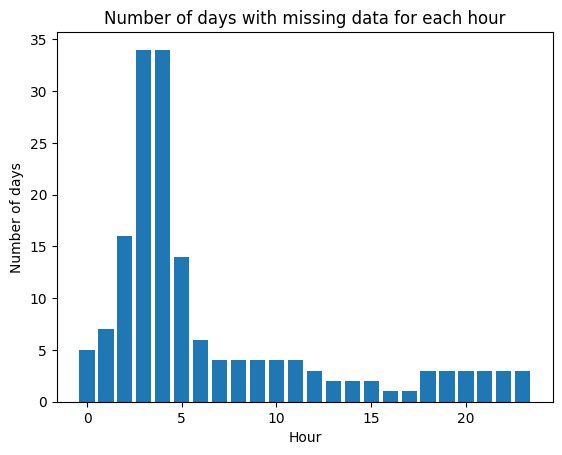

In [141]:
plt.bar(missing_hours.index, missing_hours.values)
plt.xlabel("Hour")
plt.ylabel("Number of days")
plt.title("Number of days with missing data for each hour")
plt.show()

In [147]:
df[df["hr"] == 3]["dteday"]

3       2011-01-01
27      2011-01-02
164     2011-01-08
188     2011-01-09
212     2011-01-10
           ...    
17262   2012-12-27
17286   2012-12-28
17310   2012-12-29
17334   2012-12-30
17358   2012-12-31
Name: dteday, Length: 697, dtype: datetime64[ns]

In [177]:
all_days = df["dteday"].unique()

days_with_hr3 = df[df["hr"] == 3]["dteday"].unique()

In [191]:
days_without_hr3 = set(all_days) - set(days_with_hr3)
days_without_hr3

{Timestamp('2011-01-03 00:00:00'),
 Timestamp('2011-01-04 00:00:00'),
 Timestamp('2011-01-05 00:00:00'),
 Timestamp('2011-01-06 00:00:00'),
 Timestamp('2011-01-07 00:00:00'),
 Timestamp('2011-01-11 00:00:00'),
 Timestamp('2011-01-12 00:00:00'),
 Timestamp('2011-01-18 00:00:00'),
 Timestamp('2011-01-19 00:00:00'),
 Timestamp('2011-01-25 00:00:00'),
 Timestamp('2011-01-26 00:00:00'),
 Timestamp('2011-01-27 00:00:00'),
 Timestamp('2011-02-10 00:00:00'),
 Timestamp('2011-02-11 00:00:00'),
 Timestamp('2011-02-15 00:00:00'),
 Timestamp('2011-02-22 00:00:00'),
 Timestamp('2011-03-10 00:00:00'),
 Timestamp('2011-03-15 00:00:00'),
 Timestamp('2011-04-11 00:00:00'),
 Timestamp('2011-08-28 00:00:00'),
 Timestamp('2011-09-12 00:00:00'),
 Timestamp('2011-10-19 00:00:00'),
 Timestamp('2011-12-26 00:00:00'),
 Timestamp('2012-01-02 00:00:00'),
 Timestamp('2012-01-10 00:00:00'),
 Timestamp('2012-01-17 00:00:00'),
 Timestamp('2012-02-06 00:00:00'),
 Timestamp('2012-02-21 00:00:00'),
 Timestamp('2012-04-

In [193]:
df["cnt"].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

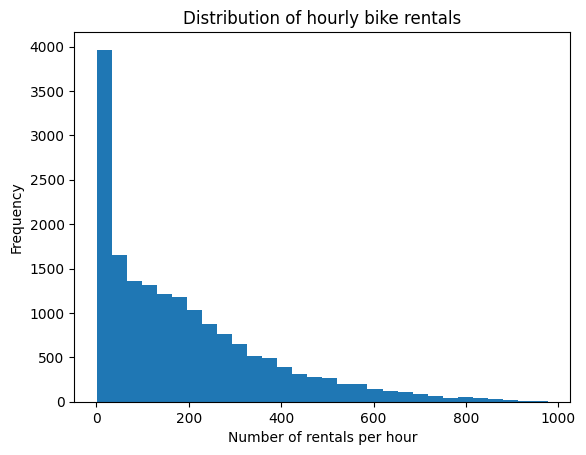

In [205]:
plt.hist(df["cnt"], bins=30)
plt.xlabel("Number of rentals per hour")
plt.ylabel("Frequency")
plt.title("Distribution of hourly bike rentals")
plt.show()

In [207]:
hourly_mean = df.groupby("hr")["cnt"].mean()
hourly_mean

hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64

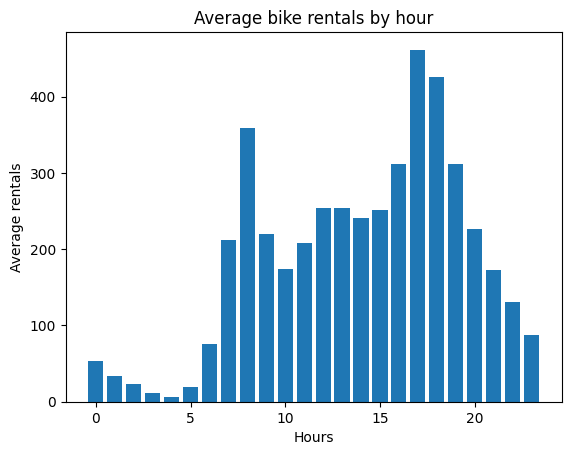

In [211]:
plt.bar(hourly_mean.index, hourly_mean.values)
plt.xlabel("Hours")
plt.ylabel("Average rentals")
plt.title("Average bike rentals by hour")
plt.show()

In [25]:
hour_workingday = df.groupby(["hr", "workingday"])["cnt"].mean()
hour_workingday

hr  workingday
0   0              90.800000
    1              36.786290
1   0              69.508696
    1              16.552632
2   0              53.171053
    1               8.683778
3   0              25.775330
    1               4.942553
4   0               8.264317
    1               5.429787
5   0               8.689189
    1              24.913131
6   0              18.742358
    1             102.500000
7   0              43.406926
    1             290.612903
8   0             105.653680
    1             477.006048
9   0             171.623377
    1             241.518145
10  0             255.909091
    1             135.366935
11  0             315.316017
    1             158.229839
12  0             366.259740
    1             200.820926
13  0             372.731602
    1             198.429719
14  0             364.645022
    1             183.572289
15  0             358.813853
    1             201.331325
16  0             352.727273
    1             293.122244

In [217]:
hour_workingday = hour_workingday.unstack()
hour_workingday

workingday,0,1
hr,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


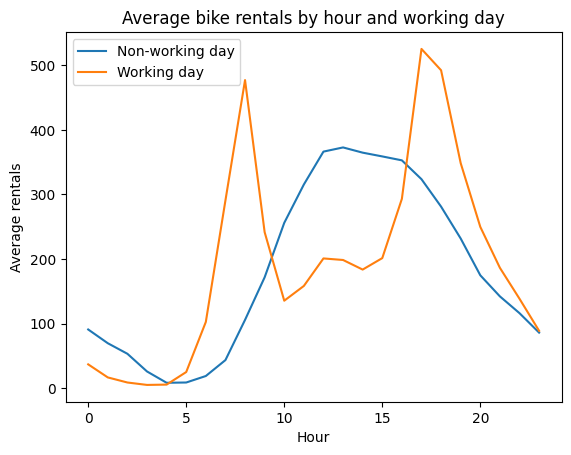

In [231]:
plt.plot(hour_workingday.index, hour_workingday[0], label="Non-working day")
plt.plot(hour_workingday.index, hour_workingday[1], label="Working day")

plt.xlabel("Hour")
plt.ylabel("Average rentals")
plt.title("Average bike rentals by hour and working day")
plt.legend()
plt.show()

In [9]:
df.groupby("season")["cnt"].mean()

season
1    111.114569
2    208.344069
3    236.016237
4    198.868856
Name: cnt, dtype: float64

In [13]:
season_hour = df.groupby(["season", "hr"])["cnt"].mean()
season_hour = season_hour.unstack()

In [33]:
season_hour

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
season,,,,,,,,,,,,,,,,,,,,,
1,27.404494,18.140449,12.794118,7.102564,3.181818,10.701754,40.792135,115.391061,235.167598,147.016760,...,147.805556,155.655556,182.314917,263.977901,239.500000,165.761111,117.838889,91.650000,69.111111,44.411111
2,56.842391,35.222826,23.380435,11.450549,6.211111,19.169399,79.070652,221.483696,380.135870,233.983696,...,265.777174,279.250000,346.907609,518.847826,483.173913,358.663043,256.983696,191.554348,146.114130,95.983696
3,73.914439,43.720430,30.731183,15.752688,8.240642,26.454545,101.315508,276.595745,421.297872,254.930851,...,282.234043,288.409574,369.765957,572.138298,547.219251,419.160428,312.860963,241.427807,184.042781,122.919786
4,56.333333,35.920455,23.765714,11.861272,7.267045,22.590909,81.681818,231.607955,396.346591,239.443182,...,266.011299,279.819209,346.903955,486.158192,426.146893,297.033898,212.141243,161.327684,123.564972,86.440678


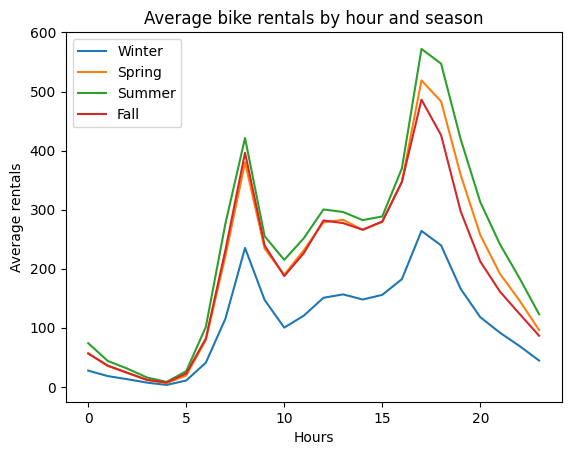

In [37]:
plt.plot(season_hour.columns, season_hour.loc[1], label='Winter')
plt.plot(season_hour.columns, season_hour.loc[2], label='Spring')
plt.plot(season_hour.columns, season_hour.loc[3], label='Summer')
plt.plot(season_hour.columns, season_hour.loc[4], label='Fall')
plt.xlabel("Hours")
plt.ylabel("Average rentals")
plt.title("Average bike rentals by hour and season")
plt.legend()
plt.show()

In [39]:
weather_mean = df.groupby("weathersit")["cnt"].mean()
weather_mean

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64

In [41]:
temp_mean = df.groupby("temp")["cnt"].mean()
temp_mean

temp
0.02     41.882353
0.04     35.625000
0.06     42.000000
0.08     28.235294
0.10     49.294118
0.12     58.421053
0.14     55.108696
0.16     65.578261
0.18     60.116129
0.20     79.745763
0.22     69.914489
0.24     80.159004
0.26     87.960644
0.28    106.750831
0.30    115.917317
0.32    134.230769
0.34    135.308527
0.36    147.842027
0.38    164.212366
0.40    167.441368
0.42    175.341241
0.44    158.907298
0.46    162.906977
0.48    190.434028
0.50    198.429379
0.52    202.967626
0.54    200.284710
0.56    213.740933
0.58    222.065574
0.60    222.081481
0.62    204.111570
0.64    223.966763
0.66    225.402597
0.68    209.538682
0.70    256.953623
0.72    286.752632
0.74    313.153101
0.76    342.575758
0.78    313.195266
0.80    347.375385
0.82    339.690141
0.84    325.818841
0.86    322.954198
0.88    363.660377
0.90    309.288889
0.92    320.020408
0.94    217.058824
0.96    274.500000
0.98    539.000000
1.00    294.000000
Name: cnt, dtype: float64

In [45]:
df["temp"].corr(df["cnt"])

0.4047722757786586

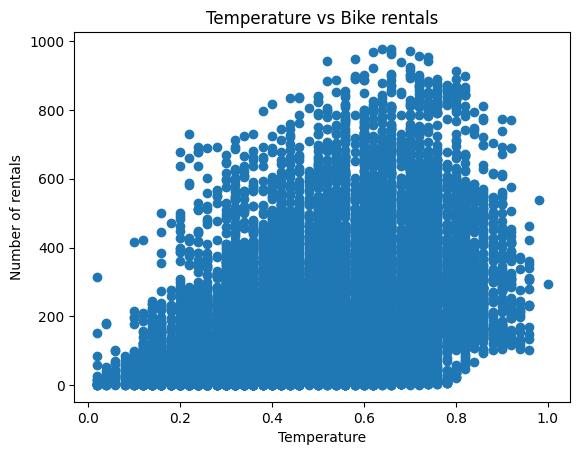

In [57]:
plt.scatter(df["temp"], df["cnt"])
plt.xlabel("Temperature")
plt.ylabel("Number of rentals")
plt.title("Temperature vs Bike rentals")
plt.show()

In [59]:
humidity_mean = df.groupby("hum")["cnt"].mean()
humidity_mean

hum
0.00     28.318182
0.08     77.000000
0.10    107.000000
0.12     29.000000
0.13     17.000000
           ...    
0.93     66.380665
0.94     93.930357
0.96    125.000000
0.97     64.000000
1.00     68.774074
Name: cnt, Length: 89, dtype: float64

In [61]:
df["hum"].corr(df["cnt"])

-0.32291074082456045

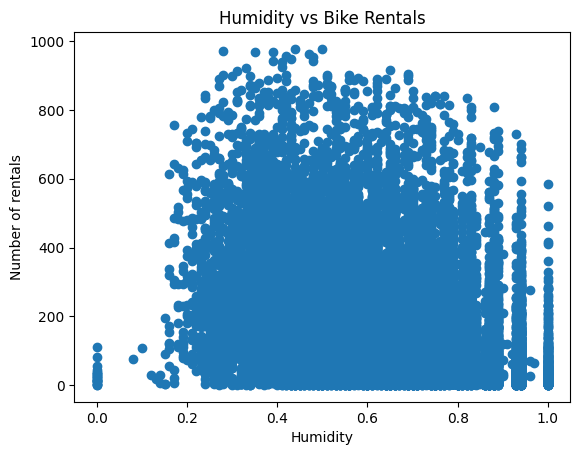

In [65]:
plt.scatter(df["hum"], df["cnt"])
plt.xlabel("Humidity")
plt.ylabel("Number of rentals")
plt.title("Humidity vs Bike Rentals")
plt.show()

In [67]:
windspeed_mean = df.groupby("windspeed")["cnt"].mean()
windspeed_mean

windspeed
0.0000    160.643578
0.0896    150.037895
0.1045    166.246753
0.1343    176.307825
0.1642    196.458997
0.1940    200.607725
0.2239    211.948447
0.2537    213.806950
0.2836    215.536260
0.2985    215.066832
0.3284    197.149502
0.3582    210.028261
0.3881    222.779528
0.4179    214.114865
0.4478    208.011364
0.4627    196.808219
0.4925    193.214286
0.5224    201.821429
0.5522    161.076923
0.5821    163.568182
0.6119    160.652174
0.6418    145.357143
0.6567    192.000000
0.6866    117.800000
0.7164    140.500000
0.7463    180.000000
0.7761      5.000000
0.8060    103.500000
0.8358     16.000000
0.8507    269.500000
Name: cnt, dtype: float64

In [69]:
df["windspeed"].corr(df["cnt"])

0.09323378392612536

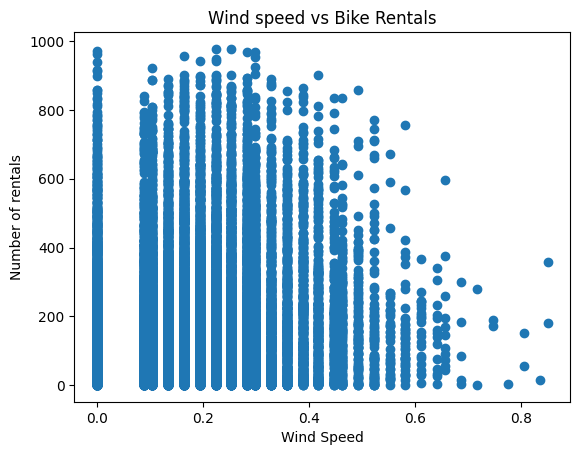

In [71]:
plt.scatter(df["windspeed"], df["cnt"])
plt.xlabel("Wind Speed")
plt.ylabel("Number of rentals")
plt.title("Wind speed vs Bike Rentals")
plt.show()

In [73]:
corr = df[["temp", "hum", "windspeed", "cnt"]].corr()
corr

,temp,hum,windspeed,cnt
temp,1.000000,-0.069881,-0.023125,0.404772
hum,-0.069881,1.000000,-0.290105,-0.322911
windspeed,-0.023125,-0.290105,1.000000,0.093234
cnt,0.404772,-0.322911,0.093234,1.000000


In [5]:
df[df["workingday"] == 1]["temp"].corr(df[df["workingday"] == 1]["cnt"])

0.35455812243234364

In [7]:
df[df["workingday"] == 0]["temp"].corr(df[df["workingday"] == 0]["cnt"])

0.5153917245393053

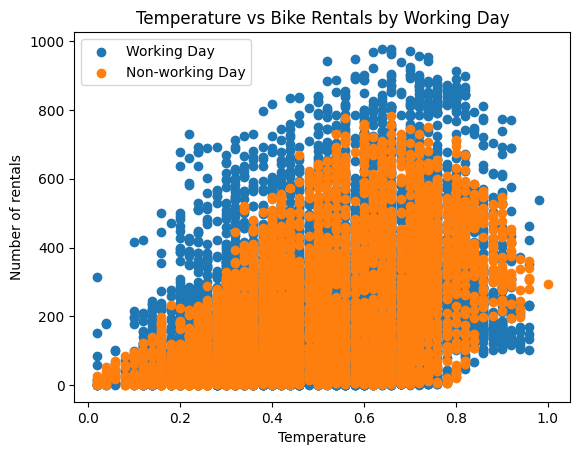

In [9]:
plt.scatter(
    df[df["workingday"] == 1]["temp"],
    df[df["workingday"] == 1]["cnt"],
    label="Working Day"
)

plt.scatter(
    df[df["workingday"] == 0]["temp"],
    df[df["workingday"] == 0]["cnt"],
    label="Non-working Day"
)

plt.xlabel("Temperature")
plt.ylabel("Number of rentals")
plt.title("Temperature vs Bike Rentals by Working Day")
plt.legend()
plt.show()

In [7]:
hourly_corr = df.groupby("hr").apply(
    lambda x: x["temp"].corr(x["cnt"]),
    include_groups=False
)

In [13]:
hourly_corr

hr
0     0.417618
1     0.273282
2     0.226855
3     0.223979
4     0.407180
5     0.412337
6     0.407829
7     0.368596
8     0.297409
9     0.427543
10    0.420670
11    0.407067
12    0.412679
13    0.396276
14    0.378465
15    0.388162
16    0.551861
17    0.587932
18    0.601334
19    0.677768
20    0.710147
21    0.720421
22    0.700642
23    0.607746
dtype: float64

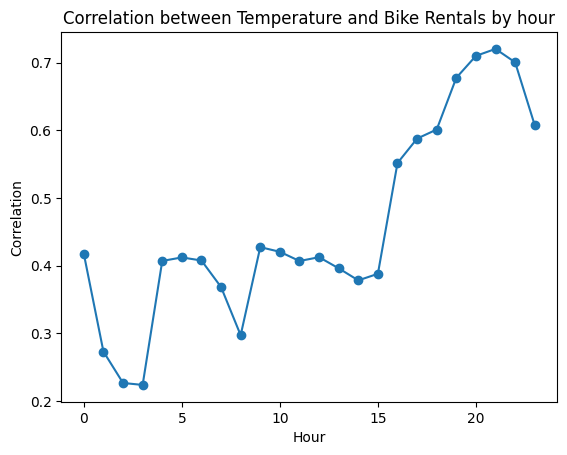

In [21]:
plt.plot(hourly_corr.index, hourly_corr.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Correlation")
plt.title("Correlation between Temperature and Bike Rentals by hour")
plt.show()

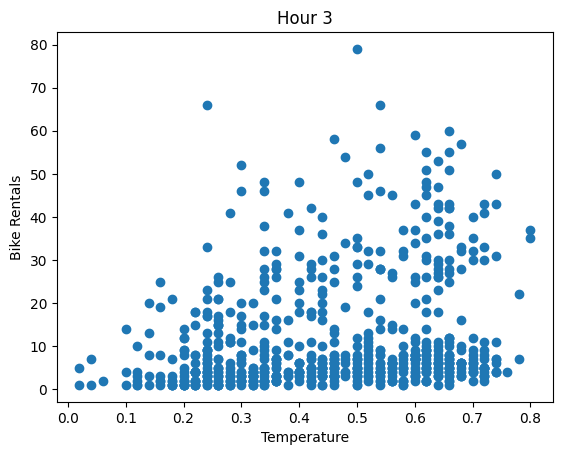

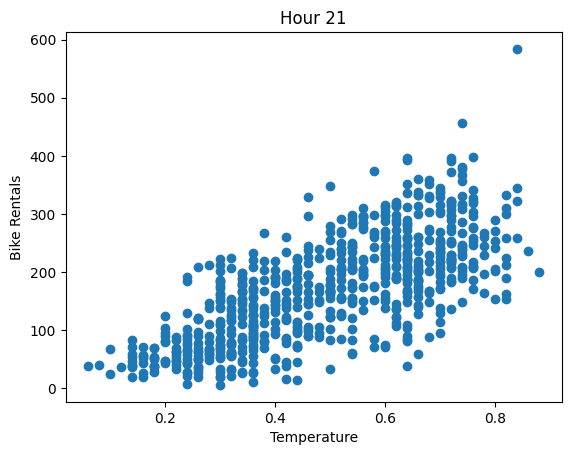

In [23]:
plt.scatter(df[df["hr"] == 3]["temp"], df[df["hr"] == 3]["cnt"])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Hour 3")
plt.show()

plt.scatter(df[df["hr"] == 21]["temp"], df[df["hr"] == 21]["cnt"])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Hour 21")
plt.show()

In [27]:
weather_hour = df.groupby(["hr", "weathersit"])["cnt"].mean()
weather_hour

hr  weathersit
0   1              59.161554
    2              47.232432
    3              28.115385
1   1              34.395918
    2              35.541899
                     ...    
22  2             116.823171
    3              70.345455
23  1              93.981707
    2              85.171598
    3              49.373134
Name: cnt, Length: 75, dtype: float64

In [35]:
weather_difference = weather_hour.groupby("hr").agg(["min", "max"])
weather_difference["difference"] = (
    weather_difference["max"] - weather_difference["min"]
)
weather_difference["difference"]

hr
0      31.046170
1      18.412270
2      10.652427
3       5.507683
4       2.037101
5       6.537136
6      23.183745
7      93.662216
8     177.507981
9      97.866879
10    114.697136
11    148.518159
12    144.720624
13    167.319803
14    147.382168
15    137.168260
16    299.745098
17    224.443138
18    294.440000
19    156.570843
20    118.663348
21     88.300195
22     72.255724
23     44.608573
Name: difference, dtype: float64

In [37]:
(df["casual"] + df["registered"] == df["cnt"]).all()

True

In [39]:
customer_type_hour = df.groupby("hr")[["casual", "registered"]].mean()
customer_type_hour

,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


In [41]:
customer_type_workingday = df.groupby(
    ["hr", "workingday"]
)[["casual", "registered"]].mean()

customer_type_workingday

casual  registered
hr workingday                        
0  0            16.647826   74.152174
   1             7.149194   29.637097
1  0            12.504348   57.004348
   1             3.710526   12.842105
2  0            10.399123   42.771930
   1             2.137577    6.546201
3  0             6.453744   19.321586
   1             0.910638    4.031915
4  0             2.264317    6.000000
   1             0.765957    4.663830
5  0             1.725225    6.963964
   1             1.270707   23.642424
6  0             3.820961   14.921397
   1             4.318548   98.181452
7  0             8.606061   34.800866
   1            12.195565  278.417339
8  0            20.424242   85.229437
   1            22.264113  454.741935
9  0            45.017316  126.606061
   1            24.312500  217.205645
10 0            79.268398  176.640693
   1            31.205645  104.161290
11 0           106.653680  208.662338
   1            37.598790  120.631048
12 0           126.246753  240.012987
   1            41.358149  159.462777
13 0           136.424242  236.307359
   1            42.568273  155.861446
14 0           139.593074  225.051948
   1            45.869478  137.702811
15 0           136.502165  222.311688
   1            46.333333  154.997992
16 0           128.614719  224.112554
   1            48.344689  244.777555
17 0           111.813853  211.735931
   1            56.895792  468.394790
18 0            84.221739  196.834783
   1            50.451807  441.775100
19 0            65.547826  166.126087
   1            41.022088  307.379518
20 0            46.765217  127.973913
   1            31.369478  218.349398
21 0            36.147826  105.913043
   1            24.610442  161.676707
22 0            28.056522   88.004348
   1            19.572289  118.817269
23 0            19.139130   66.791304
   1            13.379518   75.329317

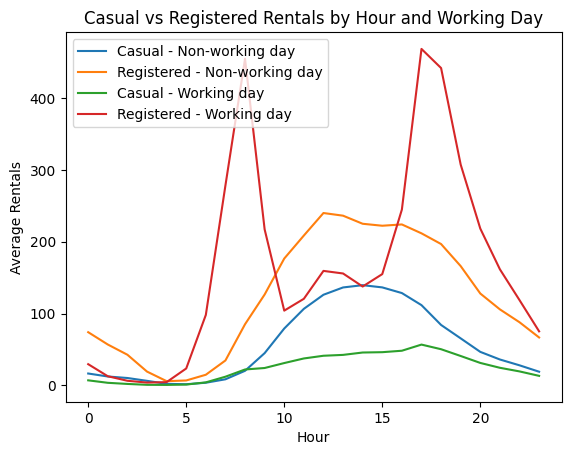

In [45]:
plt.plot(
    customer_type_workingday.xs(0, level="workingday")["casual"],
    label="Casual - Non-working day"
)

plt.plot(
    customer_type_workingday.xs(0, level="workingday")["registered"],
    label="Registered - Non-working day"
)

plt.plot(
    customer_type_workingday.xs(1, level="workingday")["casual"],
    label="Casual - Working day"
)

plt.plot(
    customer_type_workingday.xs(1, level="workingday")["registered"],
    label="Registered - Working day"
)
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Casual vs Registered Rentals by Hour and Working Day")
plt.legend()
plt.show()

In [47]:
df[["casual", "registered", "cnt"]].mean() 

casual         35.676218
registered    153.786869
cnt           189.463088
dtype: float64

In [51]:
casual_share = df["casual"].mean() / df["cnt"].mean()
registered_share = df["registered"].mean() / df["cnt"].mean()

casual_share, registered_share

(0.18830168382645254, 0.8116983161735474)

In [53]:
df.groupby("workingday")["cnt"].mean()

workingday
0    181.405332
1    193.207754
Name: cnt, dtype: float64

In [61]:
working = df[df["workingday"] == 1]["cnt"]
non_working = df[df["workingday"] == 0]["cnt"]

result = ttest_ind(working, non_working, equal_var=False)
result

TtestResult(statistic=4.095067721524371, pvalue=4.249478377549554e-05, df=11444.684511906307)

In [63]:
result.confidence_interval()

ConfidenceInterval(low=6.152999263103876, high=17.451844767972947)

In [75]:
mean_working = working.mean()
mean_non_working = non_working.mean()

pooled_std = np.sqrt(
    (working.var() + non_working.var()) / 2
)

cohens_d = (mean_working - mean_non_working) / pooled_std
cohens_d

0.06590384321379379